# Studying eating establishments in LA
You’ve decided to open a small robot-run cafe in Los Angeles. The project is promising but expensive, so you and your partners decide to try to attract investors. They’re interested in the current market conditions—will you be able to maintain your success when the novelty of robot waiters wears off?

You’re an analytics guru, so your partners have asked you to prepare some market research. You have open-source data on restaurants in LA.

### Step 1. Download the data and prepare it for analysis

In [1]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [2]:
#rest = pd.read_csv('datasets/rest_data_us.csv')

# ruta para acceder a datos en linea
rest = pd.read_csv("https://code.s3.yandex.net/datasets/rest_data_us.csv")

In [3]:
rest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB


In [4]:
rest.head()

,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY # 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD # 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20


In [5]:
rest['id'] = rest['id'].astype('str')

In [6]:
rest[rest['number'] == 0].count()

id             0
object_name    0
address        0
chain          0
object_type    0
number         0
dtype: int64

### Step 2. Data analysis

Investigate the proportions of the various types of establishments. Plot a graph.

In [7]:
rest['object_type'].unique()

array(['Cafe', 'Restaurant', 'Fast Food', 'Bakery', 'Bar', 'Pizza'],
      dtype=object)

In [8]:
grouped_rest = rest.groupby('object_type').count()
grouped_rest

,id,object_name,address,chain,number
object_type,,,,,
Bakery,283,283,283,283,283
Bar,292,292,292,292,292
Cafe,435,435,435,435,435
Fast Food,1066,1066,1066,1066,1066
Pizza,320,320,320,319,320
Restaurant,7255,7255,7255,7253,7255


C:\Users\Usuario\AppData\Local\Temp\ipykernel_18864\1598458315.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


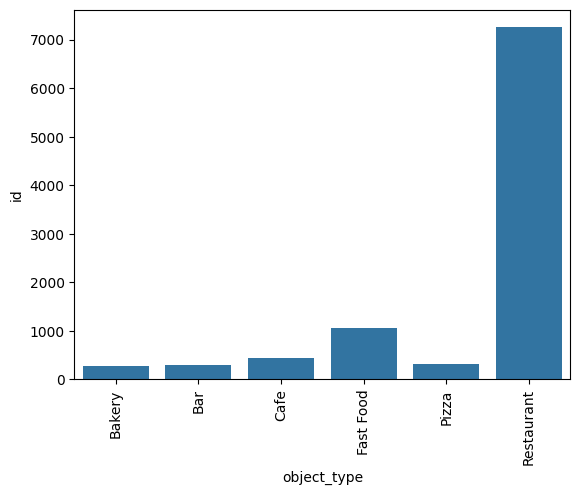

In [9]:
ax = sns.barplot(x=grouped_rest.index, y=grouped_rest['id'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()


Investigate the proportions of chain and nonchain establishments. Plot a graph.

In [10]:
grouped_chain = rest.groupby('chain').count()
grouped_chain


,id,object_name,address,object_type,number
chain,,,,,
False,5972,5972,5972,5972,5972
True,3676,3676,3676,3676,3676


C:\Users\Usuario\AppData\Local\Temp\ipykernel_18864\2734751659.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=90)


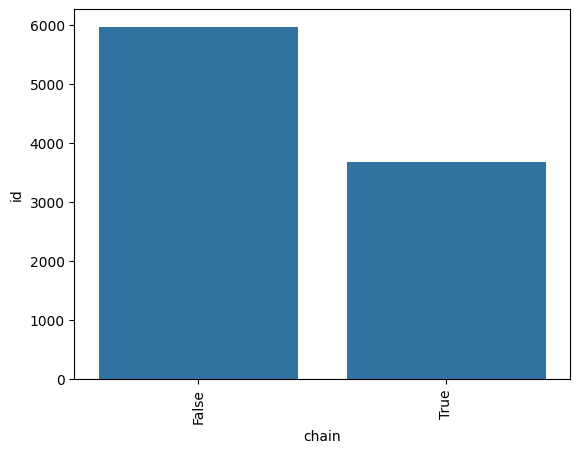

In [11]:
ax = sns.barplot(x=grouped_chain.index,y=grouped_chain['id'])
labels = ax.get_xticklabels()
ax.set_xticklabels(labels, rotation=90)
plt.show()

Which type of establishment is typically a chain?

In [12]:
grouped_chain_object = pd.pivot_table(rest, values ='object_name', index = 'object_type', columns = ['chain'], aggfunc='count')
grouped_chain_object

chain,False,True
object_type,,
Bakery,NaN,283.0
Bar,215.0,77.0
Cafe,169.0,266.0
Fast Food,461.0,605.0
Pizza,166.0,153.0
Restaurant,4961.0,2292.0


In [13]:
grouped_chain_object['ratio'] = grouped_chain_object[True]/(grouped_chain_object[True]+grouped_chain_object[False])
grouped_chain_object

chain,False,True,ratio
object_type,,,
Bakery,NaN,283.0,NaN
Bar,215.0,77.0,0.263699
Cafe,169.0,266.0,0.611494
Fast Food,461.0,605.0,0.567542
Pizza,166.0,153.0,0.479624
Restaurant,4961.0,2292.0,0.316007


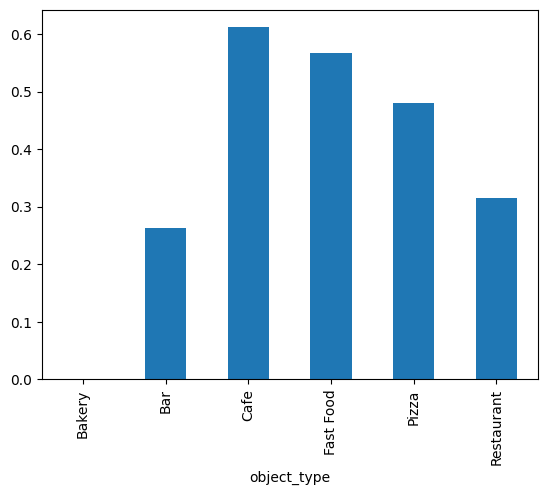

In [14]:
grouped_chain_object['ratio'].plot.bar()
plt.show()

What's typical for chains: many establishments with a small number of seats or a few establishments with a lot of seats?

In [15]:
rest_chain = rest[rest['chain']==True]

In [16]:
rest_chain['object_name'].value_counts().head()

object_name
THE COFFEE BEAN & TEA LEAF    47
SUBWAY                        31
DOMINO'S PIZZA                15
KENTUCKY FRIED CHICKEN        14
WABA GRILL                    14
Name: count, dtype: int64

In [17]:
check = rest_chain[rest_chain['object_name'] == 'KFC'].sort_values(by='number', ascending=False)
check

,id,object_name,address,chain,object_type,number
5826,17612,KFC,2801 W OLYMPIC BLVD,True,Fast Food,101
2402,14188,KFC,340 N WESTERN AVE,True,Fast Food,66
6262,18048,KFC,5130 RODEO RD,True,Fast Food,49
4307,16093,KFC,126 S VERMONT AVE # 112,True,Fast Food,37
7038,18824,KFC,4903 EAGLE ROCK BLVD,True,Fast Food,37
6909,18695,KFC,380 WORLD WAY T33,True,Fast Food,34
9054,20840,KFC,2807 S FIGUEROA ST,True,Fast Food,34
2649,14435,KFC,11864 WILMINGTON AVE,True,Fast Food,19
3781,15567,KFC,5720 S VERMONT AVE,True,Fast Food,6


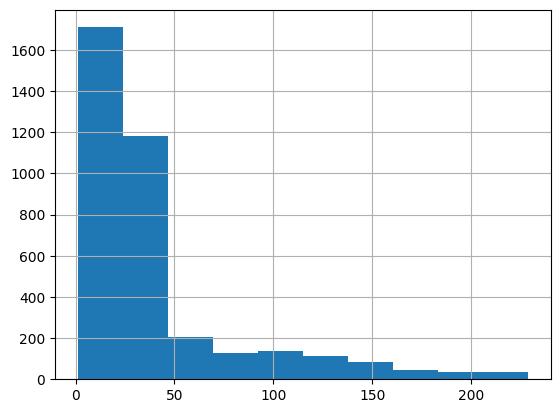

In [18]:
rest_chain.number.hist()
plt.show()

Determine the average number of seats for each type of restaurant. On average, which type of restaurant has the greatest number of seats? Plot graphs.

In [19]:
rest.groupby('object_type').agg(mean=('number','mean'),median=('number','median'))

,mean,median
object_type,,
Bakery,21.773852,18.0
Bar,44.767123,28.5
Cafe,25.000000,21.0
Fast Food,31.837711,21.0
Pizza,28.459375,18.5
Restaurant,48.042316,29.0


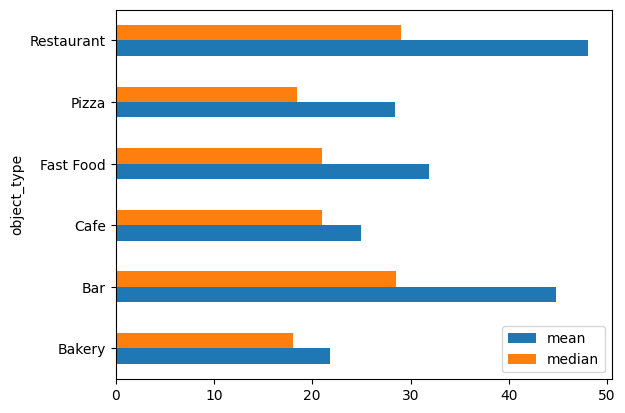

In [20]:
rest.groupby('object_type').agg(mean=('number','mean'),median=('number','median')).plot(kind='barh')
plt.show()

Put the data on street names from the address column in a separate column

In [21]:
rest_address = rest['address'].apply(lambda x: ' '.join(x.split(' ')[1:])).to_frame()
rest_address['a'] = 1
rest_address

,address,a
0,N EAGLE ROCK BLVD,1
1,WORLD WAY # 120,1
2,HOLLYWOOD BLVD # 253,1
3,W SUNSET BLVD,1
4,ECHO PARK AVE,1
...,...,...
9646,W TEMPLE AVE,1
9647,MELROSE AVE,1
9648,HOLLYWOOD BLVD,1
9649,S SPRING ST STE 100,1


Plot a graph of the top ten streets by number of restaurants.

In [22]:
rest_address_top = rest_address.groupby('address').count().sort_values(by='a', ascending = False)[0:10]
rest_address_top

,a
address,
W SUNSET BLVD,296
W PICO BLVD,288
HOLLYWOOD BLVD,167
WILSHIRE BLVD,161
S VERMONT AVE,148
SANTA MONICA BLVD,146
W 3RD ST,145
BEVERLY BLVD,135
S FIGUEROA ST,134


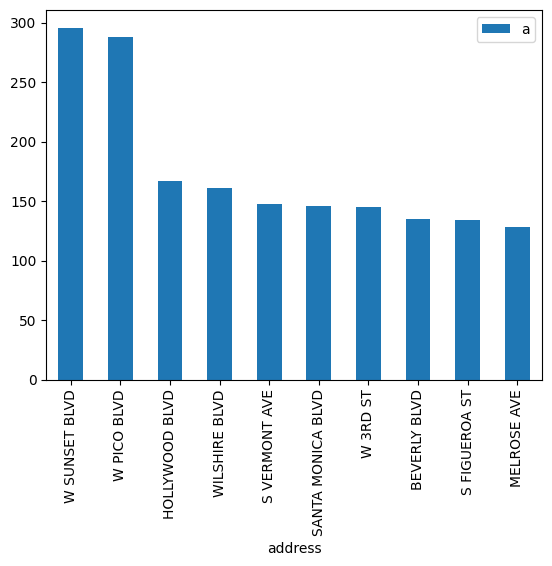

In [23]:
rest_address_top.plot.bar()
plt.show()

Find the number of streets that only have one restaurant.

In [24]:
rest_address.groupby('address').count().sort_values(by='a', ascending = False).\
loc[lambda x: x['a'] == 1].count()

a    2481
dtype: int64

For streets with a lot of restaurants, look at the distribution of the number of seats. What trends can you see?

In [25]:
rest_pr = rest[rest['address'].str.contains("W SUNSET BLVD")]
rest_pr

,id,object_name,address,chain,object_type,number
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
10,11796,EL POLLO LOCO,5319 W SUNSET BLVD,True,Restaurant,38
14,11800,CUSCATLECA BAKERY,2501 W SUNSET BLVD #A,True,Bakery,26
31,11817,DUNES RESTAURANT,5625 W SUNSET BLVD,True,Restaurant,118
33,11819,ONO HAWAIIAN BBQ,5539 W SUNSET BLVD,True,Restaurant,35
...,...,...,...,...,...,...
9498,21284,PA ORD EXPRESS,5301 W SUNSET BLVD # 11,False,Fast Food,31
9523,21309,BUTTER'S ICE CREAM,2925 W SUNSET BLVD,False,Restaurant,29
9527,21313,REGULA GUY'S PIZZA,5173 W SUNSET BLVD,False,Pizza,20
9562,21348,7-ELEVEN STORE #18778D,7600 W SUNSET BLVD,False,Restaurant,1


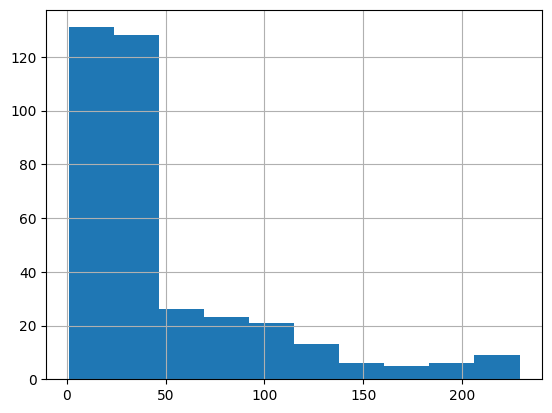

In [26]:
rest_pr.number.hist()
plt.show()